load all library

In [1]:
from tensorflow.keras import layers, models
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Dense, Embedding, SimpleRNN, Bidirectional,
    concatenate, RepeatVector, TimeDistributed
)

from tensorflow.keras.models import Model

In [2]:
import os
import numpy as np
import pandas as pd
import cv2
import re
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split

load data

In [3]:
from google.colab import files
uploaded = files.upload()

Saving dataset (2).zip to dataset (2).zip


extra zip to data

In [ ]:
import zipfile
with zipfile.ZipFile("/content/dataset (2).zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset (2)")

see inforamtion about data

In [ ]:
df = pd.read_csv("/content/dataset (2)/dataset/new_caption.csv")
images = df.iloc[:, 0]
caption = df.iloc[:, 1]
caption_ar = df.iloc[:, 2]
print("Total images:", len(images))
print("Total captions:", len(caption))
print("Total captions in Arabic:", len(caption_ar))

Total images: 10620
Total captions: 10620
Total captions in Arabic: 10620


Load Images

In [ ]:
import cv2
Images = []
image_dir = "/content/dataset (2)/dataset/images"
for i, img_name in enumerate(images):
    img_path = os.path.join(image_dir, img_name)
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Could not load {img_name}")
        continue
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    Images.append(img)

draw to ensure yhe image is done

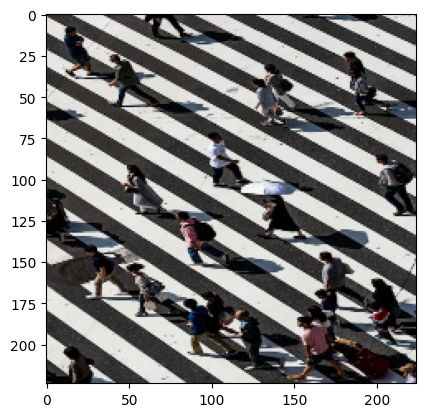

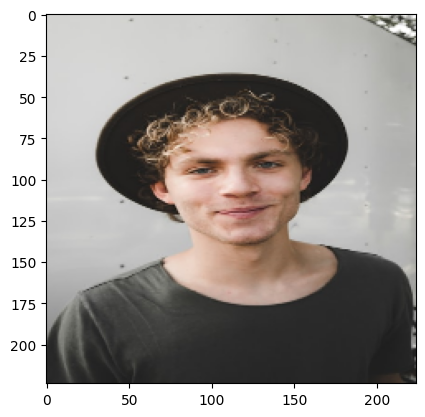

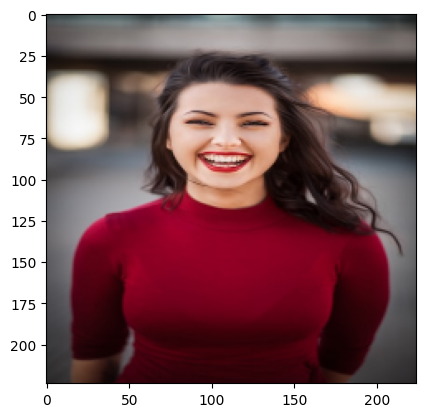

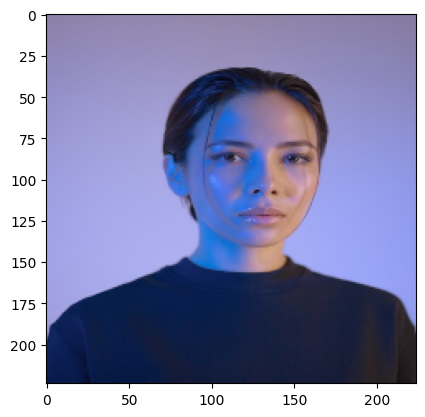

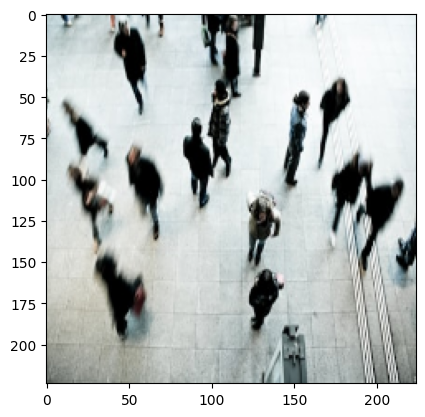

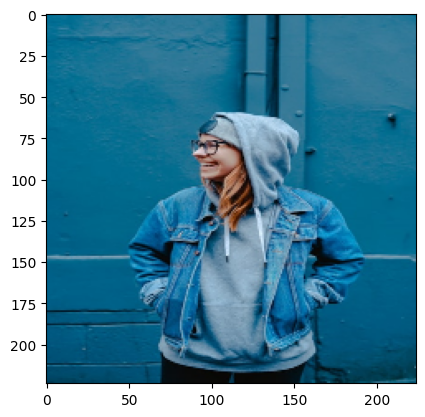

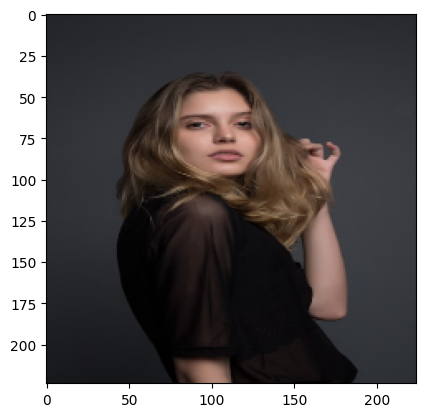

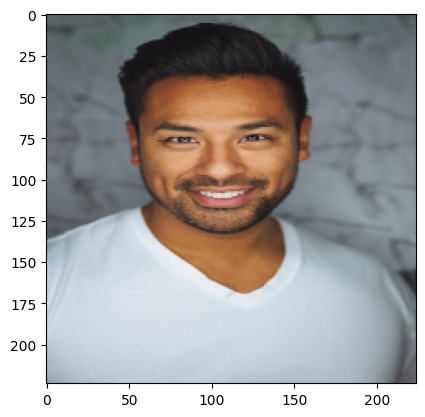

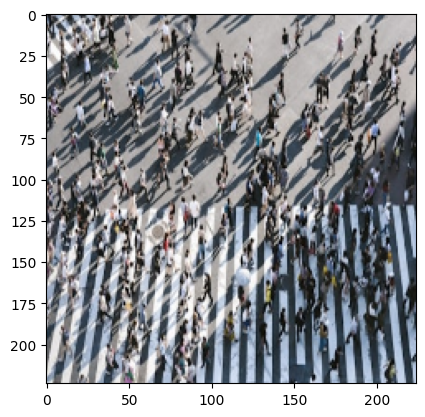

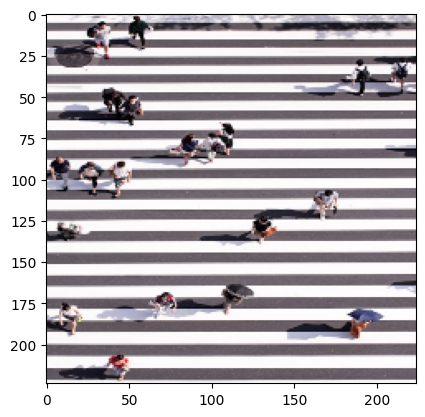

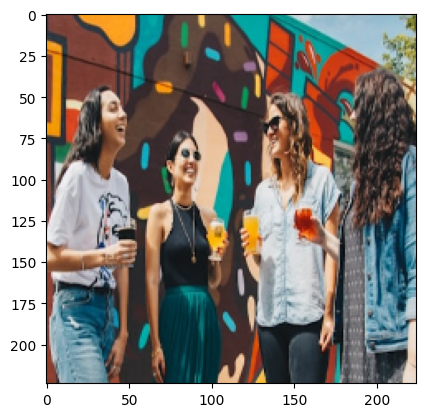

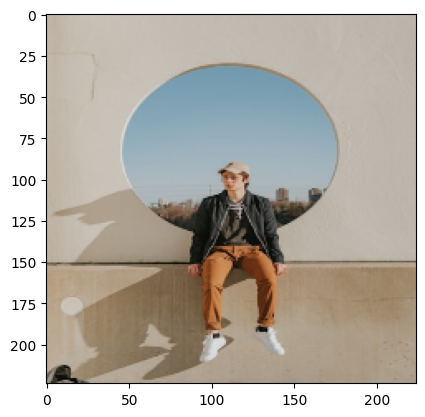

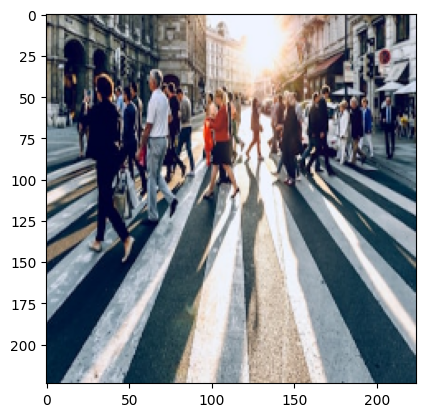

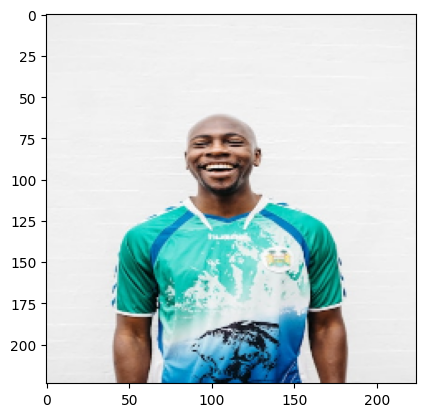

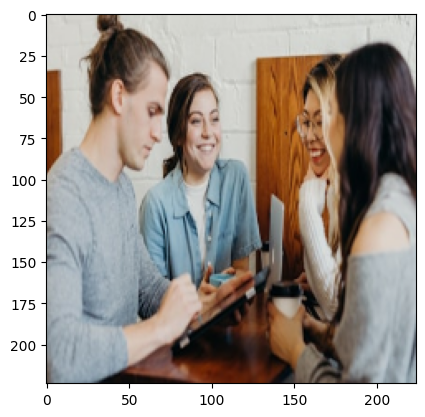

In [ ]:
import matplotlib.pyplot as plt
for i, img_name in enumerate(Images[:15]):
    plt.imshow(img_name)
    plt.show()

translator feom english to arbic and reverse

In [ ]:
from deep_translator import GoogleTranslator
captions_ar = []
for text in caption:
    try:
        translated = GoogleTranslator(source='en', target='ar').translate(text)
    except:
        translated = ""
    captions_ar.append(translated)
df["caption_ar"] = captions_ar

df.head()

In [ ]:
caption

,1
0,peoples walking on pedestrian lane
1,man standing near white wall
2,closeup photography of woman smiling
3,woman wearing black crew-neck shirt
4,people walking on grey concrete floor during d...
...,...
10615,a man laying on top of a lush green field
10616,a person holding a basketball
10617,two men playing on seashore
10618,a blue bucket filled with footballs on top of ...


clean images

In [ ]:
clean_images = []
clean_captions = []

for img, cap in zip(images, caption):
    if img is not None and cap is not None:
        clean_images.append(img)
        clean_captions.append(cap)

In [ ]:
import re
def clean_ar(text):
    text = str(text)
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub(r'ه', 'ة', text)
    return text
caption_ar = [clean_ar(t) for t in caption_ar]
caption_ar = ["<start> " + t + " <end>" for t in caption_ar]


train and spilt the data

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_temp, text_train, text_temp = train_test_split(
    Images, caption,
    test_size=0.3,
    random_state=42
)
x_val, x_test, text_val, text_test = train_test_split(
    x_temp, text_temp,
    test_size=0.5,
    random_state=42
)

In [ ]:
from sklearn.model_selection import train_test_split
x_train_ar, x_temp_ar, ar_train, ar_temp = train_test_split(
    Images, caption_ar,
    test_size=0.3,
    random_state=42
)

x_val_ar, x_test_ar, ar_val, ar_test = train_test_split(
    x_temp, ar_temp,
    test_size=0.5,
    random_state=42
)

transform images to numbers

In [ ]:
import numpy as np
x_train = np.array(x_train)
x_val = np.array(x_val)
x_test = np.array(x_test)
x_train_ar = np.array(x_train_ar)
x_val_ar = np.array(x_val_ar)
x_test_ar = np.array(x_test_ar)

augmentation to increase image

In [ ]:
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import layers
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2)
])

clean data for model

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text
text_train = [clean_text(t) for t in text_train]
text_val = [clean_text(t) for t in text_val]
text_test = [clean_text(t) for t in text_test]

In [ ]:
text_train = ["<start> " + t + " <end>" for t in text_train]
text_val = ["<start> " + t + " <end>" for t in text_val]
text_test = ["<start> " + t + " <end>" for t in text_test]


English tokenizer

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer_en = Tokenizer(num_words=15000, oov_token="<OOV>")
tokenizer_en.fit_on_texts(text_train)

seq_train = tokenizer_en.texts_to_sequences(text_train)
seq_val = tokenizer_en.texts_to_sequences(text_val)
seq_test = tokenizer_en.texts_to_sequences(text_test)

padded = pad_sequences(seq_train, maxlen=35, padding='post')
pad_val = pad_sequences(seq_val, maxlen=35, padding='post')
pad_test = pad_sequences(seq_test, maxlen=35, padding='post')

Arabic tokenizer

In [ ]:
tokenizer_ar = Tokenizer(num_words=15000, oov_token="<OOV>")
tokenizer_ar.fit_on_texts(ar_train)

seq_train_ar = tokenizer_ar.texts_to_sequences(ar_train)
seq_val_ar = tokenizer_ar.texts_to_sequences(ar_val)
seq_test_ar = tokenizer_ar.texts_to_sequences(ar_test)

ar_train_pad = pad_sequences(seq_train_ar, maxlen=35, padding='post')
ar_val_pad = pad_sequences(seq_val_ar, maxlen=35, padding='post')
ar_test_pad = pad_sequences(seq_test_ar, maxlen=35, padding='post')

learm rnn for english

In [ ]:
y_train = np.zeros_like(padded)
y_train[:, :-1] = padded[:, 1:]

y_val = np.zeros_like(pad_val)
y_val[:, :-1] = pad_val[:, 1:]

y_test = np.zeros_like(pad_test)
y_test[:, :-1] = pad_test[:, 1:]

learn for arabic

In [ ]:
def shift(x):
    y = np.zeros_like(x)
    y[:, :-1] = x[:, 1:]
    return np.expand_dims(y, -1)

y_ar_train = shift(ar_train_pad)
y_ar_val   = shift(ar_val_pad)
y_ar_test =  shift(ar_test_pad)